# Beta-distribution: Pre-requisite of Dirichlet Distribution

## Definition
- given two gamma distributed random variables with rate parameters = 1, shape parameters as alpha and beta respectively, the ratio of one of them to their sum is a random variable that's Beta distributed.
- Mathematically: $X \sim Gamma(\alpha, 1) \,,\, Y \sim Gamma(\beta, 1) \rightarrow U = \dfrac{X}{X+Y} \rightarrow U \sim Beta(\alpha, \beta)$

## P.D.F. derivation
- since U depends on multiple random variables, we would need to start with the joint probability distribution of X and Y.
- $f_X(x)(\alpha, 1) = \dfrac{(1)^\alpha x^{\alpha-1}e^{-1.x}}{\Gamma(\alpha)} \rightarrow \dfrac{x^{\alpha-1}e^{-x}}{\Gamma(\alpha)} \,,\, f_Y(y)(\beta, 1) = \dfrac{y^{\beta-1}e^{-y}}{\Gamma(\beta)}$
- joint probability $f_{XY}(x, y) = \dfrac{x^{\alpha-1}y^{\beta-1}e^{-(x+y)}}{\Gamma(\alpha)\Gamma(\beta)}$
- use the following transforms: $U = \dfrac{X}{X+Y} \,,\, T = X + Y$
- to convert the $dX\, dY$ to $dU\,dT$ we will need to evaluate the jacobian's determinant:
    - $J = \begin{bmatrix}\dfrac{\partial X}{\partial U} & \dfrac{\partial X}{\partial T} \\ \dfrac{\partial Y}{\partial U} & \dfrac{\partial Y}{\partial T} \end{bmatrix}$
        - $X = U(X+Y) \rightarrow X = UT \rightarrow \dfrac{\partial X}{\partial U} = T$
        - $X = U(X+Y) \rightarrow X = UT \rightarrow \dfrac{\partial X}{\partial T} = U$
        - $ \because \, ,\, T = X+Y \,, \, X = UT \rightarrow Y = T(1-U) \rightarrow \dfrac{\partial Y}{\partial U} = -T$
        - $Y = T(1-U) \rightarrow \dfrac{\partial Y}{\partial T} = 1-U$
    - $J = \begin{bmatrix} T & U \\ -T & 1-U \end{bmatrix} \rightarrow |J| = T - TU --TU = T $
- $\therefore \,,\, f_{U, T}(u, t) = |J| f_{XY}(x, y) = Tf_{XY}(x, y) = T. \dfrac{(ut)^{\alpha-1}(t(1-u))^{\beta-1}e^{-(t)}}{\Gamma(\alpha)\Gamma(\beta)} = \dfrac{(u)^{\alpha-1} (1-u)^{\beta-1} t^{\alpha+\beta -1-1+1} e^{-t}}{\Gamma(\alpha)\Gamma(\beta)} = \dfrac{(u)^{\alpha-1} (1-u)^{\beta-1} t^{\alpha+\beta -1} e^{-t}}{\Gamma(\alpha)\Gamma(\beta)}$
- since we had defined U to be our beta-distributed random variable, we need to marginalize the joint probability over T, i.e. integrate over the entire T-space
- $\therefore \,,\, f_U(u) = \int\limits_{0}^{\infty} f_{U, T}(u, t) dt = \int\limits_{0}^{\infty}\dfrac{(u)^{\alpha-1} (1-u)^{\beta-1} t^{\alpha+\beta -1} e^{-t}}{\Gamma(\alpha)\Gamma(\beta)} dt = \dfrac{(u)^{\alpha-1} (1-u)^{\beta-1}}{\Gamma(\alpha)\Gamma(\beta)} \int\limits_{0}^{\infty}t^{\alpha+\beta -1} e^{-t} dt = \dfrac{(u)^{\alpha-1} (1-u)^{\beta-1}.\Gamma(\alpha + \beta)}{\Gamma(\alpha)\Gamma(\beta)}$
- $\therefore \,,\, f_U(u) = \dfrac{\Gamma(\alpha + \beta)}{\Gamma(\alpha)\Gamma(\beta)} (u)^{\alpha-1} (1-u)^{\beta-1}$

## Properties
1. since X and Y are gamma distributed, they will always be positive
2. hence U will be in the range $(0,1)$ (open interval on both ends)
3. the P.D.F. can also be expressed as $f_{Beta(\alpha, \beta)} = \dfrac{\Gamma(\alpha + \beta)}{\Gamma(\alpha)\Gamma(\beta)} (u)^{\alpha-1} v^{\beta-1} \,,\, u+v = 1$
    - this is the case of the dirichlet distribution with only 2 probability parameters ($u$ and $v$) and their corresponding concentration paramters $\alpha$ and $\beta$
4. using this 2-param Dirichlet, lets see when $u << v, u < v , u ~= v, u > v, u >> v$
    1. as seen in the code cells below, for a gamma-distributed R.V. when the shape param is small, the values that the R.V. can take are also small. liekwise when the shape param is large, the values the R.V. can take are comparatively larger.
    2. so if $\alpha << \beta \rightarrow X << Y \rightarrow u << v$
    3. likewise, $\alpha < \beta \rightarrow X < Y \rightarrow u < v$,
    4. and other relations follow, based on the comparison of the concentration parameters.

In [27]:
import numpy as np
from scipy.stats import gamma, beta

import matplotlib.pyplot as plt
import seaborn as sb

- define 3 gamma-distributed R.V.s, where 
    - the first has a very small shape parameter(also called $k$ in the gamma-distribution setting)
    - the second has a medium-value of the shape parameter
    - the third has a large value of the shape parameter
- initialise their corresponding value-range
- find probabilities and plot the P.D.F.

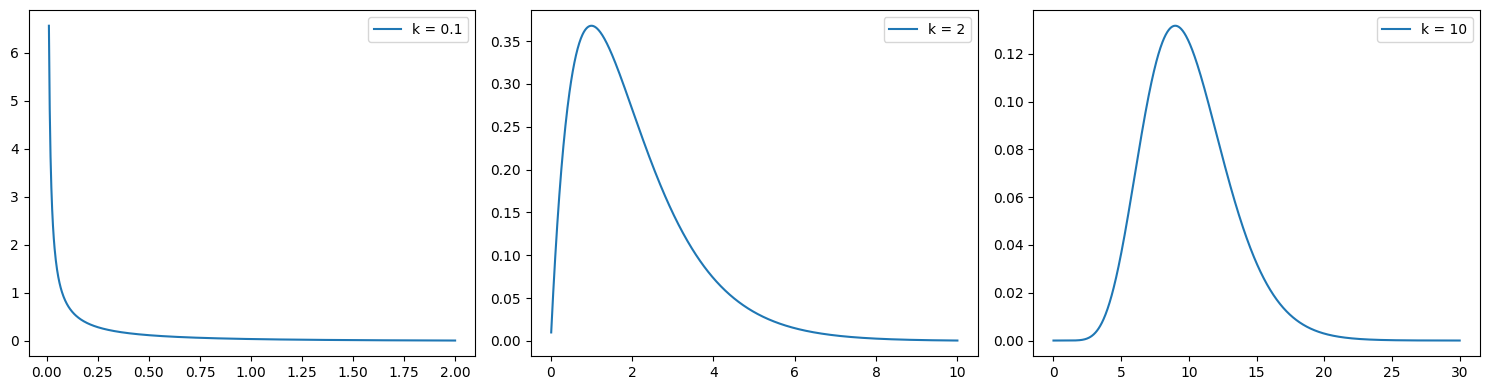

In [ ]:
small_shape_gamma, med_shape_gamma, large_shape_gamma = gamma(a = 0.1), gamma(a = 2), gamma(a = 10)

x_small = np.linspace(0.01, 2, 1000)
x_med = np.linspace(0.01, 10, 1000)
x_large = np.linspace(0.01, 30, 1000)

p_small = small_shape_gamma.pdf(x_small)
p_med = med_shape_gamma.pdf(x_med)
p_large = large_shape_gamma.pdf(x_large)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(x_small, p_small, label='k = 0.1');ax[0].legend()
ax[1].plot(x_med, p_med, label='k = 2');ax[1].legend()
ax[2].plot(x_large, p_large, label='k = 10');ax[2].legend()

plt.tight_layout()
plt.show()

- have 5 beta distributions with the following properties:
    - $\alpha << \beta$
    - $\alpha < \beta$
    - $\alpha ~= \beta$
    - $\alpha > \beta$
    - $\alpha >> \beta$
- for each, create a sample of 1000 observations and plot the density plots of the corresponding observations per case

In [26]:
beta.rvs(a=1, b=2, size=10)

array([0.03397692, 0.09220556, 0.25471343, 0.01269282, 0.84195207,
       0.50530276, 0.06391107, 0.9255874 , 0.06633492, 0.3022077 ])

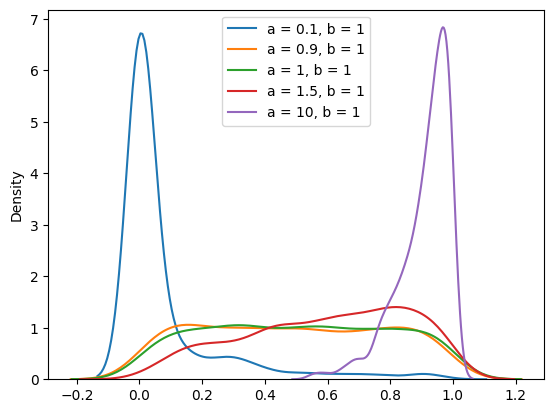

In [28]:
np.random.seed(42)

cases = {
    'a': [0.1, 0.9, 1, 1.5, 10],
    'b': [1, 1, 1, 1, 1]
}
if len(cases['a']) != len(cases['b']):
    raise Exception("no. of values initialised for a and b aren't the same")
num_vals = len(cases['a'])
for idx in range(num_vals):
    beta_i = beta(a = cases['a'][idx], b = cases['b'][idx])
    u_vals = beta_i.rvs(size = 1000)
    sb.kdeplot(u_vals, label=f"a = {cases['a'][idx]}, b = {cases['b'][idx]}")

plt.legend()
plt.show()